<a href="https://colab.research.google.com/github/patilsiddesh554-web/siddhu1/blob/main/MIL3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [16]:
iris = load_iris() # Iris flower dataset

# Create DataFrame
data = pd.DataFrame(iris.data, columns=iris.feature_names) #Features

#Add target column
data["Spcies"] = iris.target
print(data.head()) #First 5 records printed

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Spcies  
0       0  
1       0  
2       0  
3       0  
4       0  


In [17]:
data.shape #(rows, columns)

(150, 5)

In [18]:
data.info() #Structure of Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Spcies             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [19]:
#Target class distrbution
data['Spcies'].value_counts() # 0=setosa , 1 = versicolor, 2=virginica

,count
Spcies,
0,50
1,50
2,50


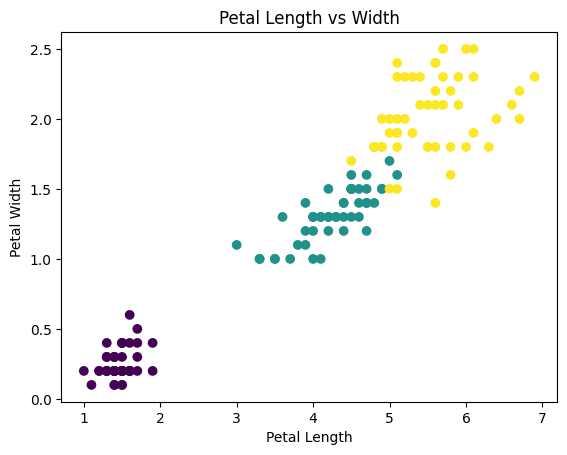

In [20]:
# Scatter Plot
plt.scatter(data['petal length (cm)'], data['petal width (cm)'], c=data['Spcies'])

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Petal Length vs Width')
plt.show()

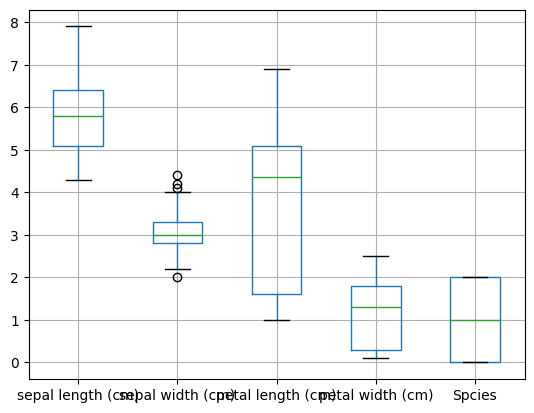

In [21]:
data.boxplot() #Used for Outliers detection
plt.show()

In [22]:
# Data Splitting
X=data.iloc[:, :4] #Independent Variables
y=data.iloc[:, -1] #Dependent Variable

In [23]:
y.head()

,Spcies
0,0
1,0
2,0
3,0
4,0


In [24]:
# Data Splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Test data=
X_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2


In [25]:
# Create Decision Tree model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train) # Train model

DecisionTreeClassifier(max_depth=3, random_state=42)

In [26]:
# Predict test data
y_pred = model.predict(X_test)
y_pred[:10]

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

In [27]:
# Classification Metrices
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Train-Test Split Results")
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred, average='weighted'))
print("Recall: ", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score: ", f1_score(y_test, y_pred, average='weighted'))

Train-Test Split Results
Accuracy:  1.0
Precision:  1.0
Recall:  1.0
F1 Score:  1.0


In [28]:
# 6. 5-fold Cross Validatin
from sklearn.model_selection import cross_validate,KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(model, X, y, cv=kf, scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])

In [29]:
# Average K-Fold Results
print("\n5-Fold Cross Validation Results")
print("Accuracy: ", np.mean(results['test_accuracy']))
print("Precision: ", np.mean(results['test_precision_weighted']))
print("Recall: ", np.mean(results['test_recall_weighted']))
print("F1 Score: ", np.mean(results['test_f1_weighted']))


5-Fold Cross Validation Results
Accuracy:  0.9533333333333334
Precision:  0.9577676767676767
Recall:  0.9533333333333334
F1 Score:  0.953277061103148
